In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
ball = Image.open("/content/Cricket_ball_on_grass.jpg")
bat = Image.open("/content/cricket_bat.jpg")
tajmahal = Image.open("/content/taj_mahal.jpg")
flower = Image.open("/content/flower.jpg")
msd = Image.open("/content/msd.jpeg")

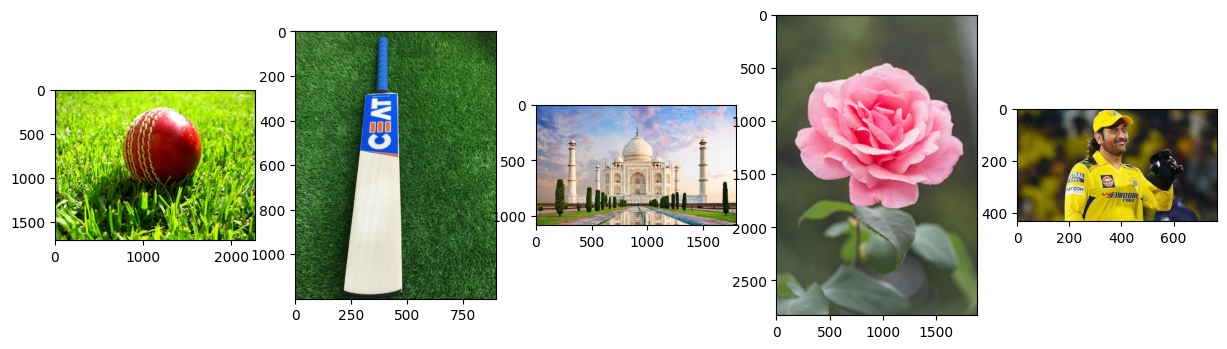

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplot(1, 5, 1)
plt.imshow(ball)

plt.subplot(1, 5, 2)
plt.imshow(bat)

plt.subplot(1, 5, 3)
plt.imshow(tajmahal)

plt.subplot(1, 5, 4)
plt.imshow(flower)

plt.subplot(1, 5, 5)
plt.imshow(msd)

In [ ]:
gray_ball = ball.convert('L').resize((128, 128))
gray_bat = bat.convert('L').resize((128,128))
gray_tajmahal = tajmahal.convert('L').resize((128,128))
gray_flower = flower.convert('L').resize((128,128))
gray_msd = msd.convert('L').resize((128,128))

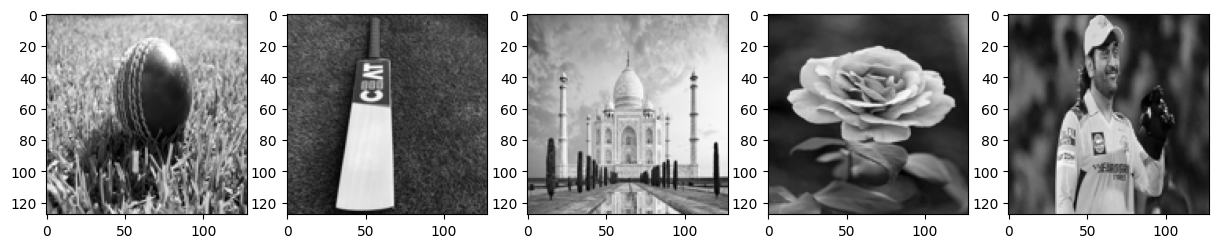

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplot(1, 5, 1)
plt.imshow(gray_ball, cmap='gray')

plt.subplot(1, 5, 2)
plt.imshow(gray_bat, cmap='gray')

plt.subplot(1, 5, 3)
plt.imshow(gray_tajmahal, cmap='gray')

plt.subplot(1, 5, 4)
plt.imshow(gray_flower, cmap='gray')

plt.subplot(1, 5, 5)
plt.imshow(gray_msd, cmap='gray')

In [ ]:
norm_ball = np.array(gray_ball) / 255.0
norm_bat = np.array(gray_bat) / 255.0
norm_tajmahal = np.array(gray_tajmahal) / 255.0
norm_flower = np.array(gray_flower) / 255.0
norm_msd = np.array(gray_msd) / 255.0

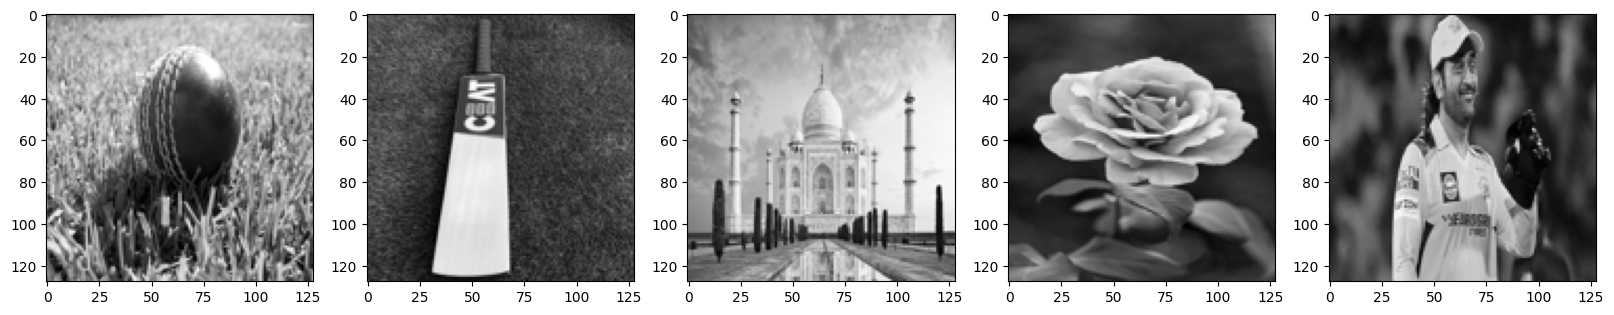

In [ ]:
plt.figure(figsize=(20, 15))
plt.subplot(1, 5, 1)
plt.imshow(norm_ball, cmap='gray')

plt.subplot(1, 5, 2)
plt.imshow(norm_bat, cmap='gray')

plt.subplot(1, 5, 3)
plt.imshow(norm_tajmahal, cmap='gray')

plt.subplot(1, 5, 4)
plt.imshow(norm_flower, cmap='gray')

plt.subplot(1, 5, 5)
plt.imshow(norm_msd, cmap='gray')

In [ ]:
# Convert images to tensors with shape (1, 128, 128, 1)
ball_tensor = tf.convert_to_tensor(norm_ball[np.newaxis, :, :, np.newaxis], dtype=tf.float32)
bat_tensor = tf.convert_to_tensor(norm_bat[np.newaxis, :, :, np.newaxis], dtype=tf.float32)
tajmahal_tensor = tf.convert_to_tensor(norm_tajmahal[np.newaxis, :, :, np.newaxis], dtype=tf.float32)
flower_tensor = tf.convert_to_tensor(norm_flower[np.newaxis, :, :, np.newaxis], dtype=tf.float32)
msd_tensor = tf.convert_to_tensor(norm_msd[np.newaxis, :, :, np.newaxis], dtype=tf.float32)

### Kernel for curved edge

In [ ]:
# kernel for horizontal edge
kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=np.float32)

In [ ]:
# Format for TensorFlow: (height, width, in_channels, out_channels)
kernel_tensor = tf.convert_to_tensor(kernel[:, :, np.newaxis, np.newaxis])

In [ ]:
# Apply kernel using tf.nn.conv2d
ball_output = tf.nn.conv2d(ball_tensor, kernel_tensor, strides=1, padding='SAME')
bat_output = tf.nn.conv2d(bat_tensor, kernel_tensor, strides=1, padding='SAME')
tajmahal_output = tf.nn.conv2d(tajmahal_tensor, kernel_tensor, strides=1, padding='SAME')
flower_output = tf.nn.conv2d(flower_tensor, kernel_tensor, strides=1, padding='SAME')
msd_output = tf.nn.conv2d(msd_tensor, kernel_tensor, strides=1, padding='SAME')

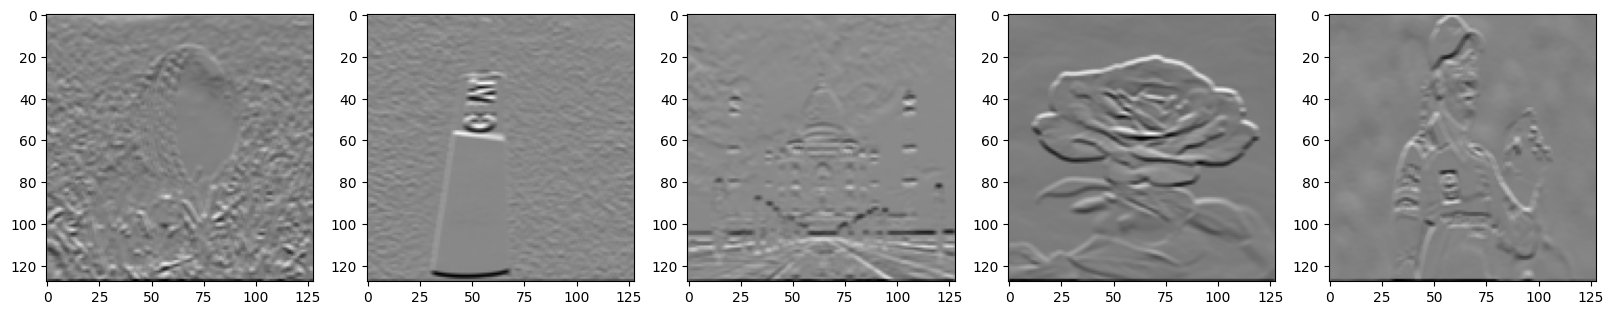

In [ ]:
# Visualize output feature maps
plt.figure(figsize=(20, 15))
plt.subplot(1, 5, 1)
plt.imshow(ball_output[0, :, :, 0], cmap='gray')

plt.subplot(1, 5, 2)
plt.imshow(bat_output[0, :, :, 0], cmap='gray')

plt.subplot(1, 5, 3)
plt.imshow(tajmahal_output[0, :, :, 0], cmap='gray')

plt.subplot(1, 5, 4)
plt.imshow(flower_output[0, :, :, 0], cmap='gray')

plt.subplot(1, 5, 5)
plt.imshow(msd_output[0, :, :, 0], cmap='gray')

### Laplacian Kernel

In [ ]:
# Laplacian kernel
laplacian = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=np.float32)

In [ ]:
# Format for TensorFlow: (height, width, in_channels, out_channels)
laplacian_tensor = tf.convert_to_tensor(laplacian[:, :, np.newaxis, np.newaxis])

In [ ]:
# Apply kernel using tf.nn.conv2d
ball_output = tf.nn.conv2d(ball_tensor, laplacian_tensor, strides=1, padding='SAME')
bat_output = tf.nn.conv2d(bat_tensor, laplacian_tensor, strides=1, padding='SAME')
tajmahal_output = tf.nn.conv2d(tajmahal_tensor, laplacian_tensor, strides=1, padding='SAME')
flower_output = tf.nn.conv2d(flower_tensor, laplacian_tensor, strides=1, padding='SAME')
msd_output = tf.nn.conv2d(msd_tensor, laplacian_tensor, strides=1, padding='SAME')

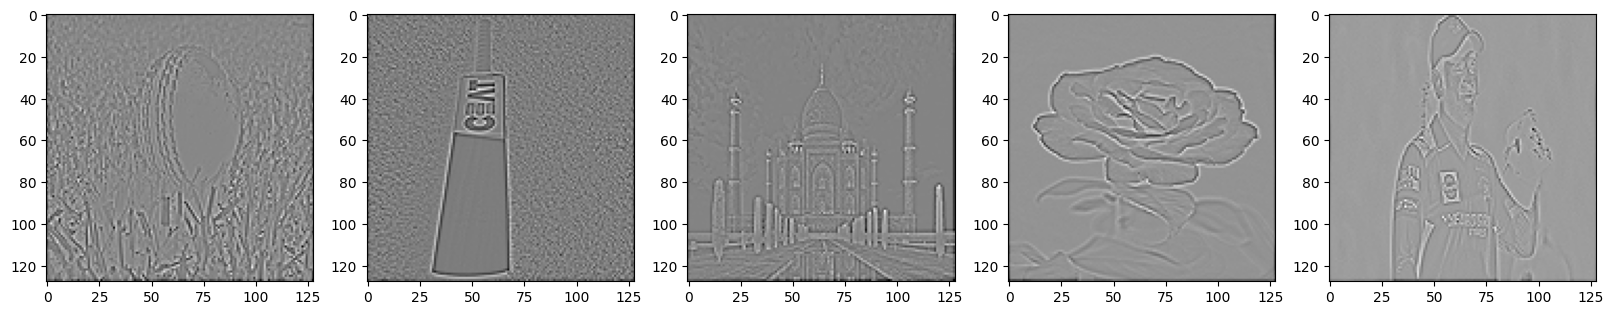

In [ ]:
# Visualize output feature maps
plt.figure(figsize=(20, 15))
plt.subplot(1, 5, 1)
plt.imshow(ball_output[0, :, :, 0], cmap='gray')

plt.subplot(1, 5, 2)
plt.imshow(bat_output[0, :, :, 0], cmap='gray')

plt.subplot(1, 5, 3)
plt.imshow(tajmahal_output[0, :, :, 0], cmap='gray')

plt.subplot(1, 5, 4)
plt.imshow(flower_output[0, :, :, 0], cmap='gray')

plt.subplot(1, 5, 5)
plt.imshow(msd_output[0, :, :, 0], cmap='gray')

### Using 4 kernels

In [ ]:
images = {
    "Ball": ball_tensor,
    "Bat": bat_tensor,
    "Taj Mahal": tajmahal_tensor,
    "Flower": flower_tensor,
    "MSD": msd_tensor
}

In [ ]:
# Define 4 filters
kernels = {
    "Horizontal": tf.constant([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=tf.float32),
    "Vertical": tf.constant([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=tf.float32),
    "Diagonal": tf.constant([[2, 1, 0], [1, 0, -1], [0, -1, -2]], dtype=tf.float32),
    "Curved": tf.constant([[1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=tf.float32)
}

In [ ]:
# Expand to shape (3, 3, 1, 1) for conv2d
kernels = {name: tf.reshape(kernel, [3, 3, 1, 1]) for name, kernel in kernels.items()}

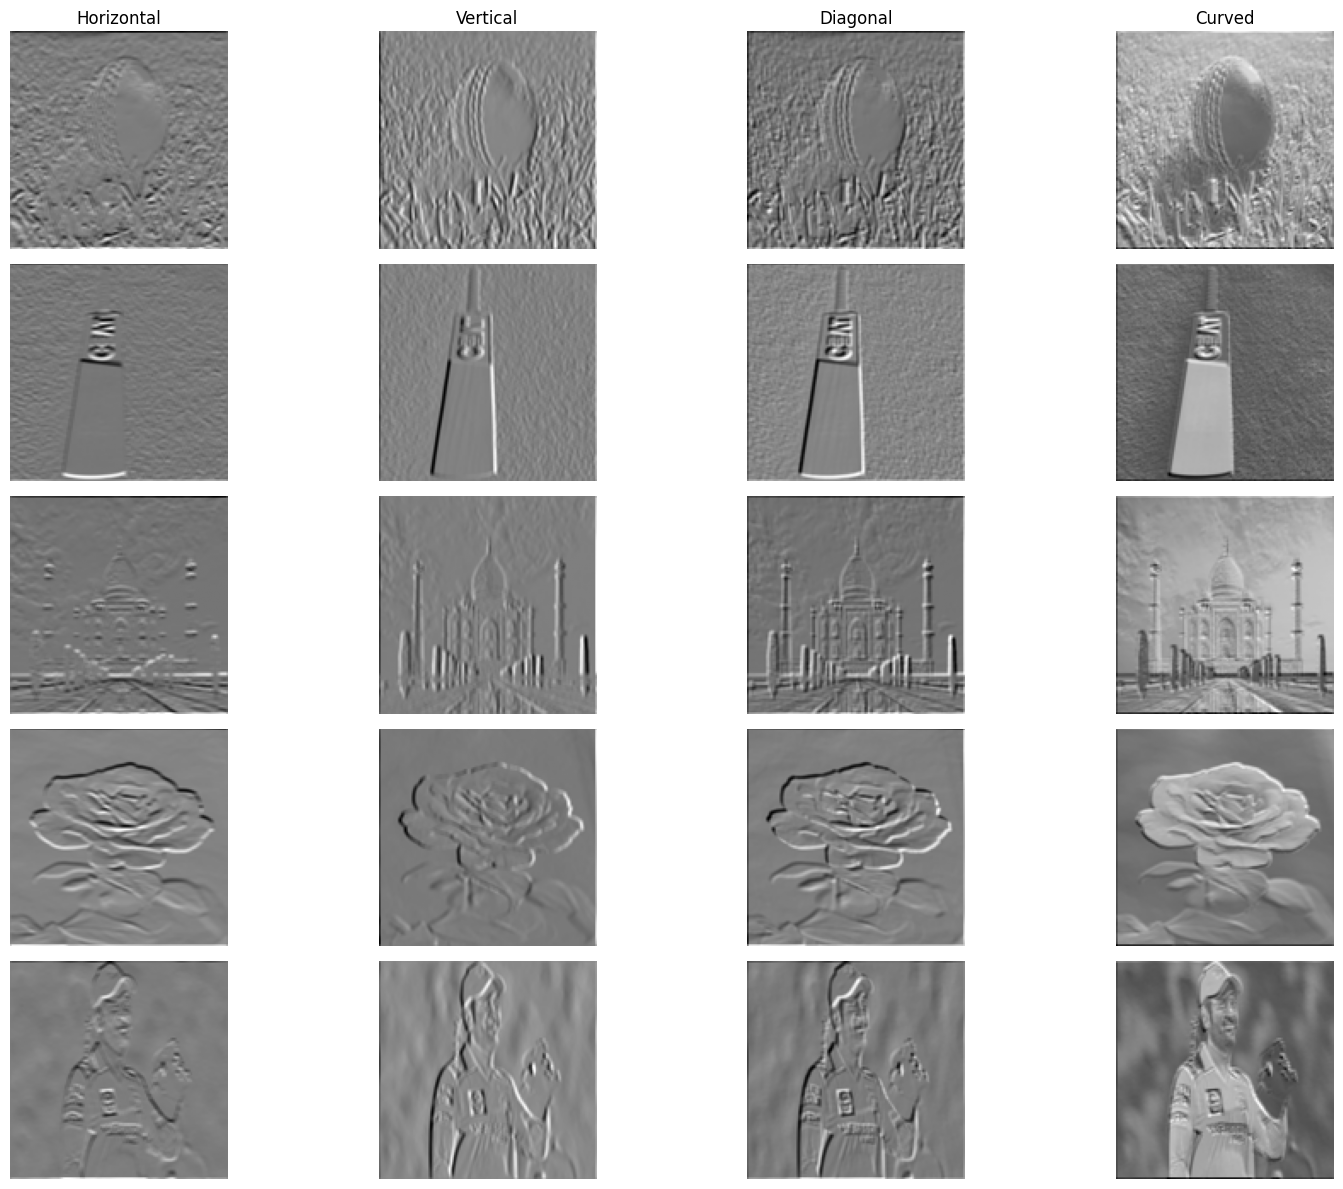

In [ ]:
# Create subplot: 5 rows (images) x 4 columns (filters)
fig, axs = plt.subplots(len(images), len(kernels), figsize=(16, 12))

for row, (img_name, img_tensor) in enumerate(images.items()):
    for col, (kernel_name, kernel_tensor) in enumerate(kernels.items()):
        # Apply convolution
        conv_result = tf.nn.conv2d(img_tensor, kernel_tensor, strides=[1, 1, 1, 1], padding="SAME")
        axs[row, col].imshow(tf.squeeze(conv_result), cmap="gray")
        axs[row, col].axis("off")
        if row == 0:
            axs[row, col].set_title(kernel_name)
        if col == 0:
            axs[row, col].set_ylabel(img_name, rotation=0, labelpad=40)

plt.tight_layout()
plt.show()

In [ ]:
# # Redefine kernel convolution using OpenCV (no TensorFlow)
# def apply_kernel_cv(image, kernel):
#     return cv2.filter2D(image, -1, kernel)

# # Apply each kernel to each image
# results_cv = {}
# for name, kernel in kernels.items():
#     results_cv[name] = {
#         "ball": apply_kernel_cv(img_ball, kernel),
#         "bat": apply_kernel_cv(img_bat, kernel),
#         "taj": apply_kernel_cv(img_taj, kernel)
#     }

# # Visualize results
# fig, axes = plt.subplots(len(kernels), 4, figsize=(16, 10))
# for i, (name, outputs) in enumerate(results_cv.items()):
#     axes[i, 0].imshow(kernels[name], cmap='gray')
#     axes[i, 0].set_title(f"{name} kernel")
#     axes[i, 0].axis('off')
#     axes[i, 1].imshow(outputs["ball"], cmap='gray')
#     axes[i, 1].set_title("Ball")
#     axes[i, 1].axis('off')
#     axes[i, 2].imshow(outputs["bat"], cmap='gray')
#     axes[i, 2].set_title("Bat")
#     axes[i, 2].axis('off')
#     axes[i, 3].imshow(outputs["taj"], cmap='gray')
#     axes[i, 3].set_title("Taj Mahal")
#     axes[i, 3].axis('off')

# plt.tight_layout()
# plt.show()